# Crypto Price Prediction — All-in-one Colab notebook

**Version 4** — Volume, volatility, Lag+Ridge, LSTM, **rolling backtest** (3b), **TimeSeriesSplit + RandomizedSearchCV** (3c), **residual plots** (3d). **Asset is a variation:** set `ASSET` in the next cell to any of `BTC-USD`, `ETH-USD`, `XRP-USD`, `ETC-USD` (or another yfinance ticker). One notebook, one version.

**Upload to Colab and run all cells.** Optional: Runtime → Change runtime type → GPU for faster LSTM.

*Versioning: pipeline versions only (v3 → v4 → v5…). When you add a new pipeline revision, move this file to `archive/` and create the next version. See `notebooks/README.md`.*

In [1]:
# === CONFIG: change asset here (not a new version — just a variation) ===
ASSET = "ETC-USD"   # e.g. "ETH-USD", "XRP-USD", "ETC-USD"

In [2]:
# Run this cell first: install packages (takes ~1 min)
!pip install -q pandas numpy yfinance pyarrow scikit-learn tensorflow matplotlib

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt

def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    n = len(y_true)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if n > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "directional_accuracy": float(dir_acc)}

# Data folder: Colab uses /content; local uses .
DATA_DIR = Path('/content/data') if Path('/content').exists() else Path('./data')
DATA_DIR.mkdir(exist_ok=True)
print("Ready. DATA_DIR =", DATA_DIR)

Ready. DATA_DIR = /content/data


---
## 1. Download data and split (70 / 15 / 15)

In [4]:
cache_name = ASSET.replace("-", "_") + "_daily.parquet"
cache_path = DATA_DIR / cache_name
if cache_path.exists():
    df = pd.read_parquet(cache_path)
    print("Loaded from cache:", cache_path, "| ASSET =", ASSET)
else:
    raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
    if raw.index.nlevels > 1:
        raw = raw.reset_index(level=1, drop=True)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    raw = raw.sort_index().ffill().dropna()
    df = raw[["Close"]].copy()
    df.columns = ["price"]
    if "Volume" in raw.columns:
        df["volume"] = raw["Volume"]
    df.to_parquet(cache_path)
    print("Downloaded and saved:", cache_path)

# Ensure volume exists (use 0 if missing)
if "volume" not in df.columns:
    df["volume"] = 0.0
# Returns (day-over-day): NaN at first row
df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
# Rolling volatility: 14-day std of returns (past only via .rolling)
df["volatility_14"] = df["ret"].rolling(14).std()
# Log volume for scale
df["log_volume"] = np.log1p(df["volume"])
# Drop leading rows where volatility is NaN (optional; lag/LSTM will align)
df = df.copy()

n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]
print(df.shape, "| Train", len(train_df), "Val", len(val_df), "Test", len(test_df))

Downloaded and saved: /content/data/ETC_USD_daily.parquet
(3031, 5) | Train 2121 Val 455 Test 455


---
## 2. Baselines (last value, 7-day MA)

In [5]:
prices = test_df["price"].values
y_true = prices[1:]
pred_last = prices[:-1]
m_last = regression_metrics(y_true, pred_last)

window = 7
pred_ma = np.array([np.mean(prices[i - window : i]) for i in range(window, len(prices))])
y_true_ma = y_true[window - 1 :]
m_ma = regression_metrics(y_true_ma, pred_ma)

print("Last value:", m_last)
print("7-day MA:  ", m_ma)

Last value: {'mae': 0.5746859348818069, 'rmse': 0.8706137441819611, 'directional_accuracy': 0.0}
7-day MA:   {'mae': 0.8942986349670253, 'rmse': 1.304841923916631, 'directional_accuracy': 0.5525727069351231}


In [ ]:
# 7-day MA forecast from end of series (out-of-sample: next day and next 7 days)
price_full = df["price"].values
window = 7
last_7 = price_full[-window:]
next_day_ma = np.mean(last_7)
# Recursive: each following day's 7-day MA uses previous forecasts to extend the window
forecasts_7 = []
window_prices = list(last_7)
for _ in range(7):
    f = np.mean(window_prices)
    forecasts_7.append(f)
    window_prices = window_prices[1:] + [f]
print("Last 7 prices:", last_7)
print("7-day MA forecast for next day:", next_day_ma)
print("7-day MA forecasts for next 7 days:", np.array(forecasts_7))

---
## 3. Lag model (Ridge + 30 lags)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

N_LAGS = 30
price_full = df["price"].values
log_vol_full = df["log_volume"].values
vol_full = np.nan_to_num(df["volatility_14"].values, nan=0.0)

def build_lag_features(price, n_lags):
    T = len(price)
    X_list = [price[n_lags - lag : T - lag] for lag in range(1, n_lags + 1)]
    X = np.column_stack(X_list)[:-1]
    y = price[n_lags + 1 :]
    return X, y

X_train, y_train = build_lag_features(train_df["price"].values, N_LAGS)
X_val, y_val = build_lag_features(val_df["price"].values, N_LAGS)
X_test, y_test = build_lag_features(test_df["price"].values, N_LAGS)

# Add volume and rolling volatility (aligned to last lag index per sample)
def add_vol_volatility(X, y, start_idx, n_lags):
    n = len(y)
    idx = start_idx + n_lags
    extra = np.column_stack([log_vol_full[idx : idx + n], vol_full[idx : idx + n]])
    return np.hstack([X, extra])

X_train = add_vol_volatility(X_train, y_train, 0, N_LAGS)
X_val   = add_vol_volatility(X_val,   y_val,   train_end, N_LAGS)
X_test  = add_vol_volatility(X_test,  y_test,  val_end, N_LAGS)

n_f = X_train.shape[1]
pipe = Pipeline([
    ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_f)))], remainder="passthrough")),
    ("ridge", Ridge(alpha=1.0)),
])
pipe.fit(X_train, y_train)
pred_lag = pipe.predict(X_test)
m_lag = regression_metrics(y_test, pred_lag)
print("Lag+Ridge (+ volume, volatility_14):", m_lag)

Lag+Ridge (+ volume, volatility_14): {'mae': 0.8943907335316735, 'rmse': 1.1769589202928064, 'directional_accuracy': 0.5342789598108747}


---
## 3b. Rolling backtest (Lag+Ridge)

Train on past only, predict next day, roll forward. No future leakage. Uses same features (30 lags + log_volume + volatility_14).

In [7]:
def rolling_backtest_lag(df, n_lags, model_factory, min_train=500):
    """Rolling backtest: at each end, train on df.iloc[:end], predict next-day price. No future leakage."""
    price = df["price"].values
    log_vol = df["log_volume"].values
    vol = np.nan_to_num(df["volatility_14"].values, nan=0.0)
    T = len(price)
    preds, actuals = [], []
    for end in range(min_train + n_lags + 1, T):
        p_slice = price[:end]
        lv_slice = log_vol[:end]
        v_slice = vol[:end]
        X_tr, y_tr = build_lag_features(p_slice, n_lags)
        extra = np.column_stack([lv_slice[n_lags : n_lags + len(y_tr)], v_slice[n_lags : n_lags + len(y_tr)]])
        X_tr = np.hstack([X_tr, extra])
        model = model_factory(X_tr.shape[1])
        model.fit(X_tr, y_tr)
        last_row = np.hstack([p_slice[end - 1 - n_lags : end - 1][::-1], [log_vol[end - 1], vol[end - 1]]]).reshape(1, -1)
        preds.append(model.predict(last_row)[0])
        actuals.append(price[end])
    return np.array(preds), np.array(actuals)

def make_lag_pipe(n_features):
    return Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_features)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=1.0)),
    ])

backtest_preds, backtest_actuals = rolling_backtest_lag(df, N_LAGS, make_lag_pipe, min_train=500)
m_roll = regression_metrics(backtest_actuals, backtest_preds)
print("Rolling backtest (Lag+Ridge + vol, volatility_14):", m_roll)

Rolling backtest (Lag+Ridge + vol, volatility_14): {'mae': 1.3837706319146785, 'rmse': 3.48934547737854, 'directional_accuracy': 0.5274109643857543}


---
## 3c. TimeSeriesSplit + RandomizedSearchCV

Tune Ridge alpha with time-series cross-validation. Param grid: alpha in logspace.

In [8]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {"ridge__alpha": np.logspace(-2, 2, 20)}
search = RandomizedSearchCV(
    pipe, param_distributions=param_grid, n_iter=10, cv=tscv,
    scoring="neg_mean_absolute_error", random_state=42
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

Best params: {'ridge__alpha': np.float64(0.01)}
Best CV MAE: 1.6389267647696695


---
## 3d. Evaluation: residual plots and error discussion

Best Lag+Ridge model on test set; residual distribution and predicted vs actual. Short note on where the model performs poorly.

Test set (best Lag+Ridge from CV): {'mae': 0.8948113172092178, 'rmse': 1.1776521481366182, 'directional_accuracy': 0.5319148936170213}


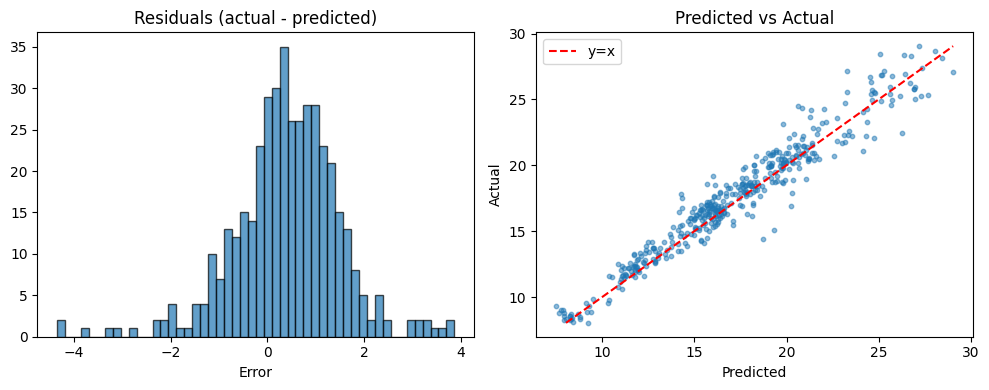

In [9]:
pred_lag_best = search.predict(X_test)
metrics_best = regression_metrics(y_test, pred_lag_best)
print("Test set (best Lag+Ridge from CV):", metrics_best)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
residuals = y_test - pred_lag_best
axes[0].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Residuals (actual - predicted)")
axes[0].set_xlabel("Error")
axes[1].scatter(pred_lag_best, y_test, alpha=0.5, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="y=x")
axes[1].set_title("Predicted vs Actual")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].legend()
plt.tight_layout()
plt.show()
# Error discussion: residuals centered near 0 with long tails; model tends to under/overpredict in large moves (volatility regimes).

---
## 4. LSTM

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 30
price = df["price"].values.astype(np.float64)
T = len(price)
# Returns: r[t] = (price[t+1] - price[t]) / price[t]
returns = (price[1:] - price[:-1]) / (price[:-1] + 1e-12)
returns = returns.astype(np.float32)
log_vol = df["log_volume"].values.astype(np.float32)
vol = np.nan_to_num(df["volatility_14"].values, nan=0.0).astype(np.float32)

def build_seq_multifeature(ret, log_vol, vol, start, end, seq_len):
    """Build sequences [ret, log_volume, volatility] per step; predict next return."""
    X_list = []
    y_list = []
    for i in range(start, min(end, len(ret) - 1)):
        if i >= seq_len:
            # Features at steps i-seq_len .. i-1 (all past)
            X_list.append(np.column_stack([
                ret[i - seq_len : i],
                log_vol[i - seq_len : i],
                vol[i - seq_len : i],
            ]))
            y_list.append(ret[i])
    if not X_list:
        return np.zeros((0, seq_len, 3), dtype=np.float32), np.array([], dtype=np.float32)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

X_tr, y_tr = build_seq_multifeature(returns, log_vol, vol, SEQ_LEN, train_end, SEQ_LEN)
X_va, y_va = build_seq_multifeature(returns, log_vol, vol, train_end, val_end, SEQ_LEN)
X_te, y_te = build_seq_multifeature(returns, log_vol, vol, val_end, T - 1, SEQ_LEN)

# Scale inputs (fit on train; shape n, seq_len, 3)
scaler = StandardScaler()
n_tr, seq_len, n_feat = X_tr.shape
X_tr_flat = X_tr.reshape(-1, n_feat)
scaler.fit(X_tr_flat)
X_tr = scaler.transform(X_tr_flat).reshape(-1, seq_len, n_feat).astype(np.float32)
X_va = scaler.transform(X_va.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)
X_te = scaler.transform(X_te.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)

model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, n_feat)),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(16),
    layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=30, batch_size=32, verbose=0)

pred_ret = model.predict(X_te, verbose=0).ravel()
# Convert predicted return to price for comparison with other models (same test period)
test_start_price_idx = val_end
price_prev = price[test_start_price_idx : test_start_price_idx + len(pred_ret)]
pred_lstm_price = price_prev * (1 + pred_ret)
y_true_price = price[test_start_price_idx + 1 : test_start_price_idx + 1 + len(pred_ret)]
m_lstm = regression_metrics(y_true_price, pred_lstm_price)
print("LSTM (+ volume, volatility_14, predict returns → price):", m_lstm)

LSTM (+ volume, volatility_14, predict returns → price): {'mae': 0.5996681266675862, 'rmse': 0.9038758100145166, 'directional_accuracy': 0.4446902654867257}


---
## 5. Comparison table

In [11]:
rows = [
    ["Last value", m_last["mae"], m_last["rmse"], m_last["directional_accuracy"]],
    ["7-day MA", m_ma["mae"], m_ma["rmse"], m_ma["directional_accuracy"]],
    ["Lag+Ridge", m_lag["mae"], m_lag["rmse"], m_lag["directional_accuracy"]],
    ["LSTM", m_lstm["mae"], m_lstm["rmse"], m_lstm["directional_accuracy"]],
]
print(pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "Dir.Acc"]).to_string(index=False))

     Model      MAE     RMSE  Dir.Acc
Last value 0.574686 0.870614 0.000000
  7-day MA 0.894299 1.304842 0.552573
 Lag+Ridge 0.894391 1.176959 0.534279
      LSTM 0.599668 0.903876 0.444690
